In [181]:
import torch
torch.__version__

'2.9.1+cpu'

In [182]:
from sklearn.datasets import make_blobs

In [183]:
x, y = make_blobs(n_features=2, n_samples=500, centers=4)

In [184]:
x[:5], y[:15]

(array([[ 0.60836503, -3.501184  ],
        [ 8.56717834,  9.73244345],
        [-0.2360405 ,  4.17117918],
        [ 7.96295297, -1.68798919],
        [ 0.39463371, -7.11178999]]),
 array([3, 0, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 0, 0, 3]))

In [185]:
import matplotlib.pyplot as plt

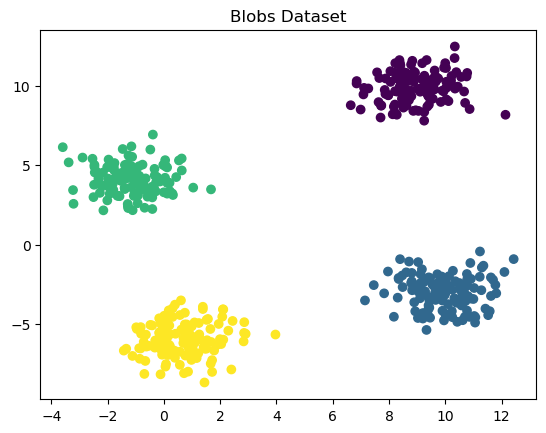

In [186]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.title("Blobs Dataset")
plt.show()

In [187]:
X = torch.from_numpy(x).type(torch.float)
Y = torch.from_numpy(y).type(torch.LongTensor)

In [188]:
X[:5], Y[:15]

(tensor([[ 0.6084, -3.5012],
         [ 8.5672,  9.7324],
         [-0.2360,  4.1712],
         [ 7.9630, -1.6880],
         [ 0.3946, -7.1118]]),
 tensor([3, 0, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 0, 0, 3]))

In [189]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [190]:
len(x_train), len(x_test)

(400, 100)

In [191]:
from torch import nn

In [192]:
class MultiLabelModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=4)
        )
    def forward(self, x):
        return self.layer(x)
        

In [193]:
model = MultiLabelModel()

In [194]:
model

MultiLabelModel(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=4, bias=True)
  )
)

In [195]:
with torch.inference_mode():
    logits = model(x_train[0])

logits

tensor([-0.2629, -0.1237, -0.6977, -0.9432])

In [196]:
prediction_probabilities = torch.softmax(logits, dim=0).argmax(dim=0)
prediction_probabilities

tensor(1)

In [197]:
def accuracy_fn(yt, yp):
    t = torch.eq(yt, yp).sum().item()
    a = (t/len(yt)) * 100
    return a

A = torch.Tensor([1,2,3,4])
B = torch.Tensor([1,9,0,4])
accuracy_fn(A,B)

50.0

In [200]:
from torch.optim import SGD
from torch.nn import CrossEntropyLoss

criterion = CrossEntropyLoss()
optimizer = SGD(params=model.parameters(), lr=0.1)

In [201]:
from tqdm import tqdm

In [205]:
EPOCH = []
TRAINING_ACC = []
TRAINING_LOSS = []
TESTING_ACC = []
TESTING_LOSS = []

for epoch in tqdm(range(10)):
    model.train()
    logits = model(x_train)
    pred_ppl = torch.softmax(logits, dim=1).argmax(dim=1)
    loss = criterion(logits, y_train)
    acc = accuracy_fn(pred_ppl, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.inference_mode():
        model.eval()
        test_logits = model(x_test)
        test_ppl = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = criterion(test_logits, y_test)
        test_acc = accuracy_fn(test_ppl, y_test)

        if epoch % 2 == 0:
            print(f"EPOCH: {epoch}")
            print(f"Training Accuracy: {acc:.2f} || Testing Accuracy: {test_acc:.2f}")
            print(f"Training Loss: {loss:.5f} || Testing Loss: {test_loss:.5f}")
            EPOCH.append(epoch)
            TRAINING_ACC.append(acc)
            TRAINING_LOSS.append(loss.item())
            TESTING_ACC.append(test_acc)
            TESTING_LOSS.append(test_loss.item())

100%|██████████| 10/10 [00:00<00:00, 361.79it/s]

EPOCH: 0
Training Accuracy: 81.25 || Testing Accuracy: 75.00
Training Loss: 0.53290 || Testing Loss: 0.55889
EPOCH: 2
Training Accuracy: 88.00 || Testing Accuracy: 87.00
Training Loss: 0.49756 || Testing Loss: 0.51973
EPOCH: 4
Training Accuracy: 94.75 || Testing Accuracy: 94.00
Training Loss: 0.45968 || Testing Loss: 0.47638
EPOCH: 6
Training Accuracy: 97.00 || Testing Accuracy: 95.00
Training Loss: 0.41837 || Testing Loss: 0.42874
EPOCH: 8
Training Accuracy: 98.00 || Testing Accuracy: 96.00
Training Loss: 0.37402 || Testing Loss: 0.37846


In [206]:
TRAINING_ACC, TESTING_ACC, TESTING_LOSS, TRAINING_LOSS

([81.25, 88.0, 94.75, 97.0, 98.0],
 [75.0, 87.0, 94.0, 95.0, 96.0],
 [0.5588855743408203,
  0.5197269320487976,
  0.4763753414154053,
  0.42873984575271606,
  0.37845534086227417],
 [0.5329014658927917,
  0.49755874276161194,
  0.4596780836582184,
  0.4183655083179474,
  0.37402117252349854])

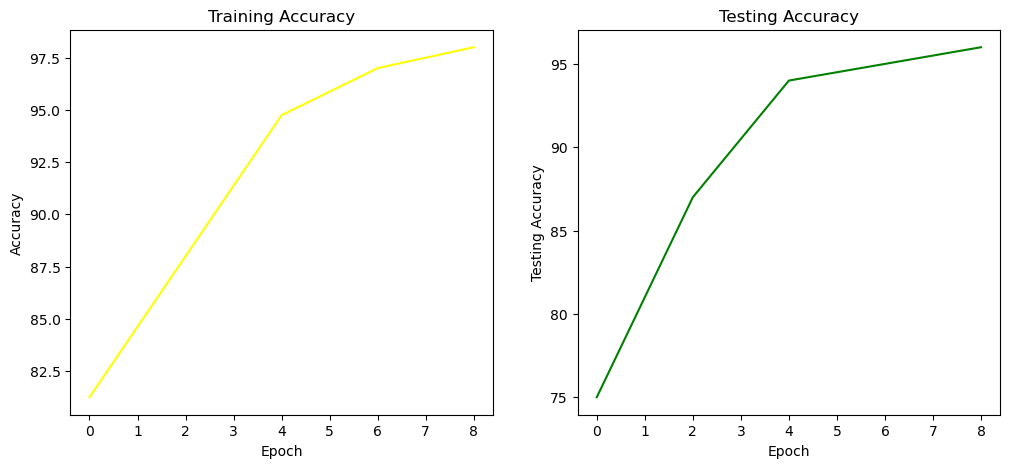

In [209]:
fig, ax =plt.subplots(1,2, figsize=(12,5))
ax[0].plot(EPOCH, TRAINING_ACC, c="yellow")
ax[0].set_title("Training Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[1].plot(EPOCH, TESTING_ACC, c="green")
ax[1].set_title("Testing Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Testing Accuracy")
plt.show()

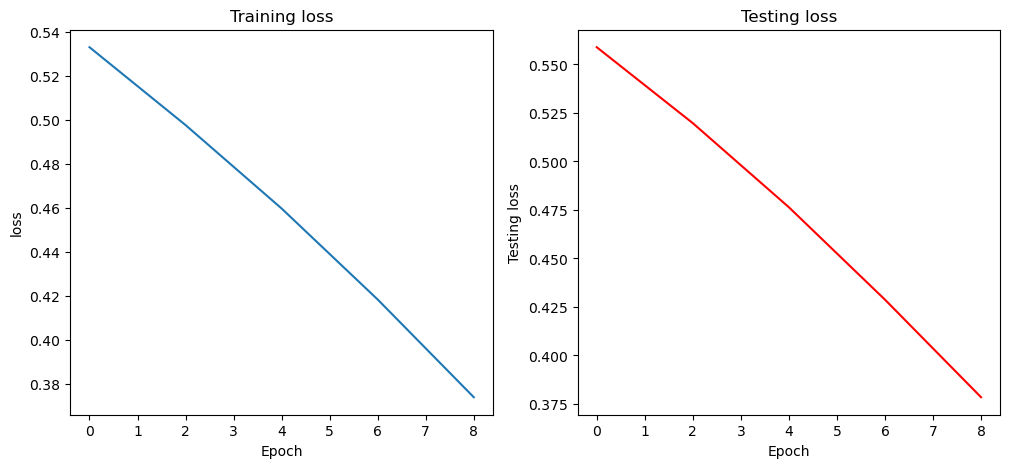

In [210]:
fig, ax =plt.subplots(1,2, figsize=(12,5))
ax[0].plot(EPOCH, TRAINING_LOSS)
ax[0].set_title("Training loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("loss")
ax[1].plot(EPOCH, TESTING_LOSS, c="red")
ax[1].set_title("Testing loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Testing loss")
plt.show()